# The running share

A histogram depends on the bins you chose. An empirical cumulative curve does not. Sort the sample. At a value $t$, the curve is the share of observations that are $t$ or smaller:

$$
F(t) = \frac{\#\{x_i \le t\}}{n}
$$

Eight shift totals from week A:

$$
4, 6, 6, 7, 8, 8, 8, 10
$$

$$
\begin{aligned}
F(4) &= 1/8 \\
F(6) &= 3/8 \\
F(7) &= 4/8 = 1/2 \\
F(8) &= 7/8 \\
F(10) &= 1
\end{aligned}
$$

Half of week A's shifts finished $7$ or fewer jobs. The curve is a step. It stays flat between observed values because no new observation has arrived yet.


In [1]:
# Running share for week A, checked at every distinct value.
from fractions import Fraction

week_a = [4, 6, 6, 7, 8, 8, 8, 10]

def running_share(samples, t):
    return Fraction(sum(value <= t for value in samples), len(samples))

assert running_share(week_a, 4) == Fraction(1, 8)
assert running_share(week_a, 6) == Fraction(3, 8)
assert running_share(week_a, 7) == Fraction(1, 2)
assert running_share(week_a, 8) == Fraction(7, 8)
assert running_share(week_a, 10) == 1
assert running_share(week_a, 5) == Fraction(1, 8)
print("F(7)", running_share(week_a, 7))


F(7) 1/2


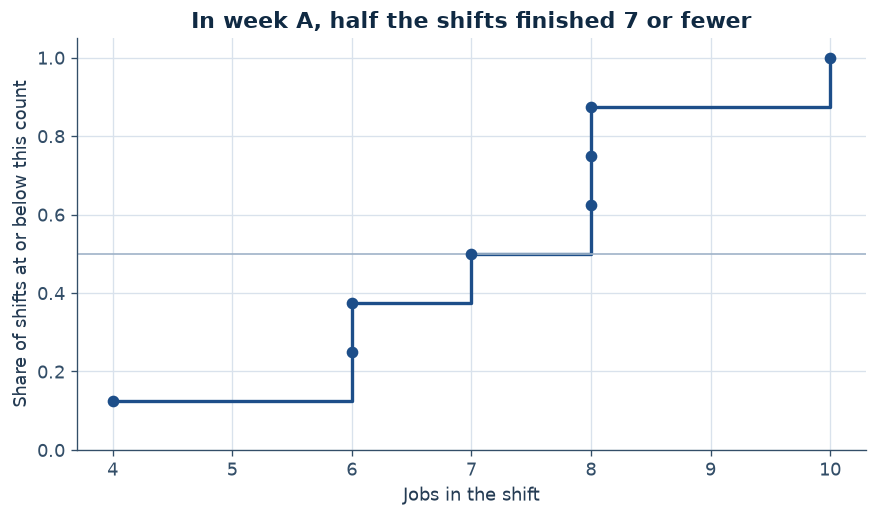

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# A step, not a diagonal. The height at 7 is 1/2.
week_a = [4, 6, 6, 7, 8, 8, 8, 10]
ordered = sorted(week_a)
shares = [i / len(ordered) for i in range(1, len(ordered) + 1)]
fig, ax = plt.subplots(constrained_layout=True)
ax.step(ordered, shares, where="post", color=BLUE, linewidth=2)
ax.scatter(ordered, shares, color=BLUE, zorder=3)
ax.axhline(0.5, color=GRAY, linewidth=1)
ax.set_xlabel("Jobs in the shift")
ax.set_ylabel("Share of shifts at or below this count")
ax.set_ylim(0, 1.05)
ax.set_title("In week A, half the shifts finished 7 or fewer")
assert shares[ordered.index(7)] == 0.5


## Two weeks on one step chart

Week B:

$$
5, 6, 7, 7, 8, 9, 9, 10
$$

At $7$, week B also has $4/8 = 1/2$. The weeks are not copies. At $8$,

$$
F_A(8) = 7/8, \qquad F_B(8) = 5/8
$$

By $8$ jobs, week A has already accounted for $7$ of its $8$ shifts. Week B has accounted for $5$. Week B still has more of its shifts above $8$, so week B sits higher. A curve that stays to the right is the larger workload.


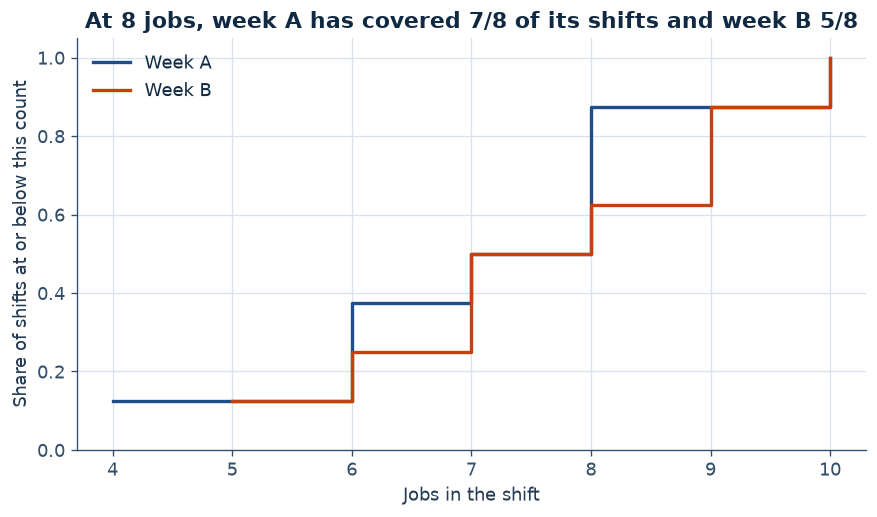

In [3]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Week B stays to the right at the top of the curve: more large shifts.
from fractions import Fraction

week_a = [4, 6, 6, 7, 8, 8, 8, 10]
week_b = [5, 6, 7, 7, 8, 9, 9, 10]

def running_share(samples, t):
    return Fraction(sum(value <= t for value in samples), len(samples))

assert running_share(week_a, 8) == Fraction(7, 8)
assert running_share(week_b, 8) == Fraction(5, 8)
assert running_share(week_b, 7) == Fraction(1, 2)
fig, ax = plt.subplots(constrained_layout=True)
for sample, color, label in (
    (week_a, BLUE, "Week A"),
    (week_b, CLAY, "Week B"),
):
    ordered = sorted(sample)
    shares = [i / len(ordered) for i in range(1, len(ordered) + 1)]
    ax.step(ordered, shares, where="post", color=color, linewidth=2, label=label)
ax.set_xlabel("Jobs in the shift")
ax.set_ylabel("Share of shifts at or below this count")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False)
ax.set_title("At 8 jobs, week A has covered 7/8 of its shifts and week B 5/8")


## A pitfall

Drawing the cumulative curve as a straight line between the first and last point claims a smooth pile you did not observe. Use a step. Also, $F(7) = 1/2$ in both weeks does not mean the weeks match. Compare the curve at more than one place. At $8$, they already differ by $7/8 - 5/8 = 1/4$.

## What to carry forward

$F(t)$ is a count of observations at or below $t$, divided by $n$. Week A reaches one half at $7$ jobs. Week B has the heavier upper end.
